# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1410]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [1411]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

Всем известными способами (https://www.geeksforgeeks.org/python/python-program-multiply-two-matrices/, https://labex.io/ru/tutorials/numpy-efficient-numpy-array-multiplication-operations-5007) находим предсказания. Находим количество объектов https://numpy.org/doc/stable/reference/generated/numpy.shape.html. Найти норму вектора с помощью https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html, также могли бы без этого обойтись, но это удобнее

In [1412]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        components = X.shape[0]
        pred = np.dot(X, w)
        return 1 / components * (np.linalg.norm(pred - y)) ** 2

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        components = X.shape[0]
        pred = np.dot(X, w)
        return 2 / components * X.T @ (pred - y)

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [1413]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

За основу взята реализация со страницы https://www.geeksforgeeks.org/machine-learning/how-to-implement-a-gradient-descent-in-python-to-find-a-local-minimum/, переделанная под нужды задания: то есть сохранение траектории

In [1414]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    traec = [w_init]

    for iter in range(n_iterations):
      gradient = loss.calc_grad(X, y, traec[-1])
      traec.append(traec[-1] - lr * gradient)

    return traec

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [1415]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [1416]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.5891768045025
0.8670644395649495


In [1417]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

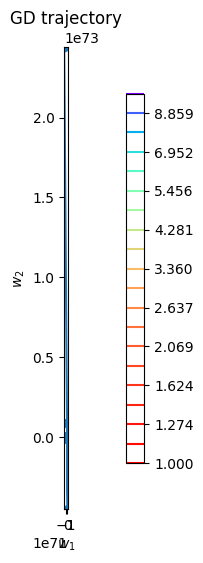

In [1418]:
w_list = gradient_descent(w_init, X, y, loss, 0.04, 100)

plot_gd(w_list, X, y, loss)

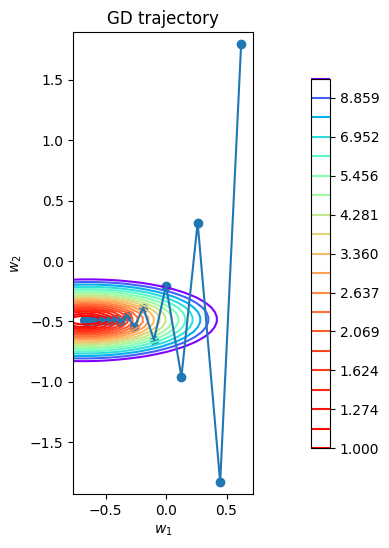

In [1419]:
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)

plot_gd(w_list, X, y, loss)

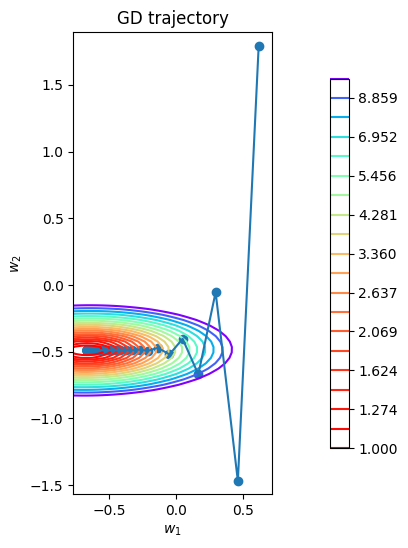

In [1420]:
w_list = gradient_descent(w_init, X, y, loss, 0.009, 100)

plot_gd(w_list, X, y, loss)

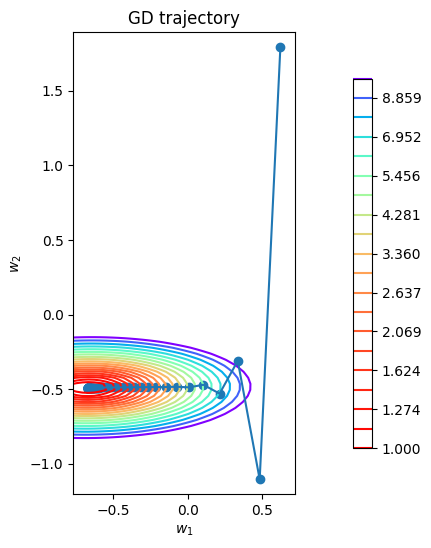

In [1421]:
w_list = gradient_descent(w_init, X, y, loss, 0.008, 100)

plot_gd(w_list, X, y, loss)

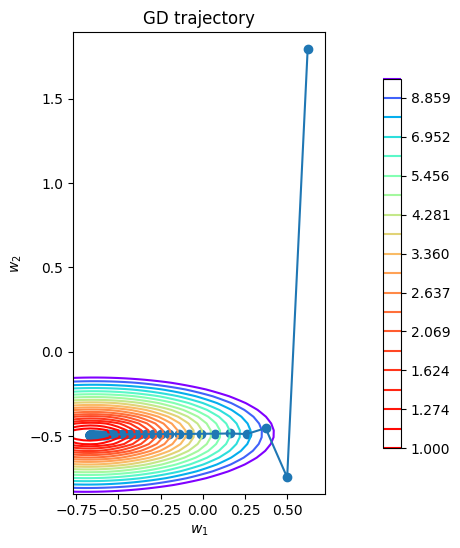

In [1422]:
w_list = gradient_descent(w_init, X, y, loss, 0.007, 100)

plot_gd(w_list, X, y, loss)

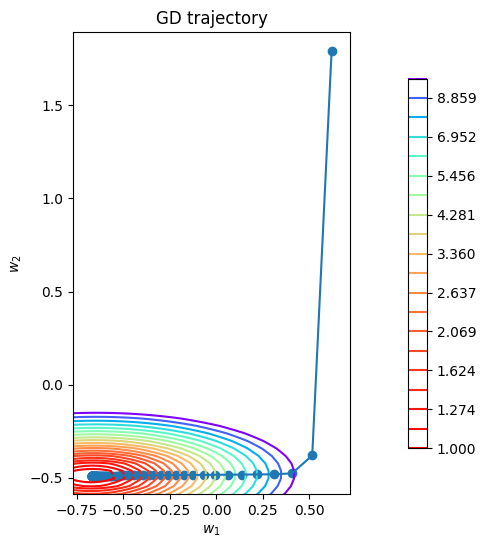

In [1423]:
w_list = gradient_descent(w_init, X, y, loss, 0.006, 100)

plot_gd(w_list, X, y, loss)

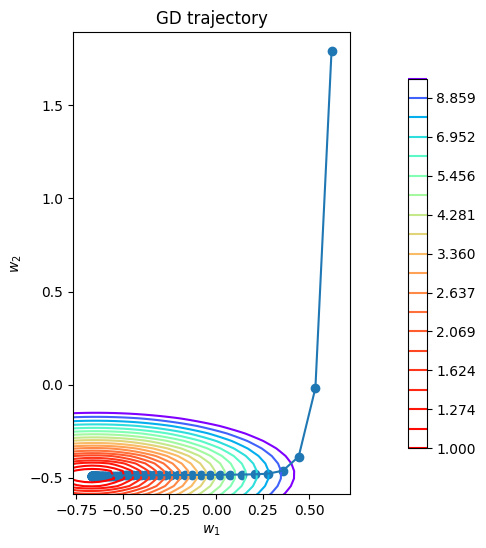

In [1424]:
w_list = gradient_descent(w_init, X, y, loss, 0.005, 100)

plot_gd(w_list, X, y, loss)

При значениях learning rate больше 0.01 градиентный спуск расходится, то есть вот этого шага достаточно чтобы начать уходить не ближе к минимуму и в вверх по возрастанию. Именно поэтому при lr = 0.04 сверху на шкале есть отметка 1e73

При уменьшении lr градиентный спуск (траетория) выглядит все более плавнее и плавнее, но сходимость идет медленнее, то есть до достижения минимума проходит большее количество точек, чем это нужно было раньше

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

Согласно подсказке из задания берём

In [1425]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """


    traec = [w_init]

    for iter in range(n_iterations):
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      batch = X[batch_indices]
      gradient = loss.calc_grad(batch, y[batch_indices], traec[-1])
      traec.append(traec[-1] - lr * gradient)

    return traec

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

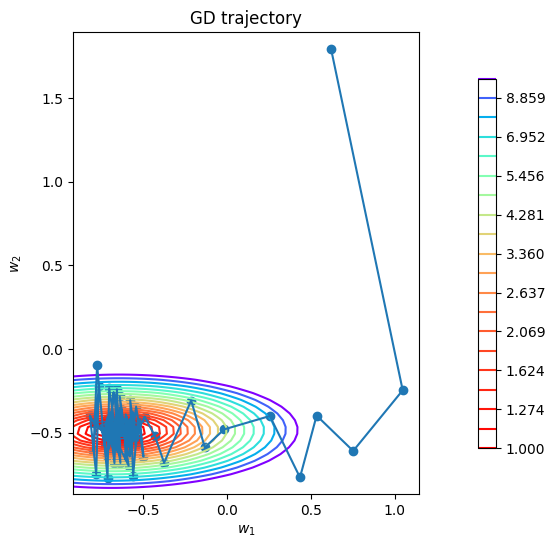

In [1426]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.011, 7, 100)

plot_gd(w_list, X, y, loss)

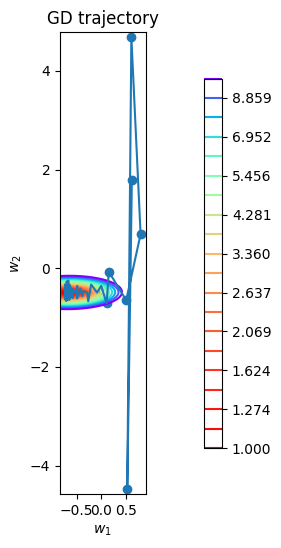

In [1427]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.011, 15, 100)

plot_gd(w_list, X, y, loss)

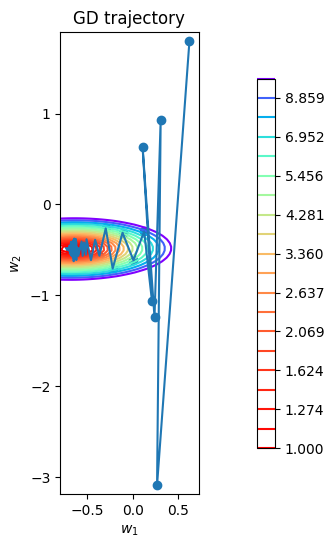

In [1428]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.011, 30, 100)

plot_gd(w_list, X, y, loss)

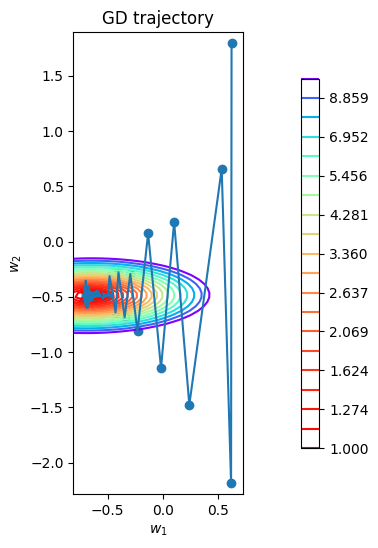

In [1429]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.011, 50, 100)

plot_gd(w_list, X, y, loss)

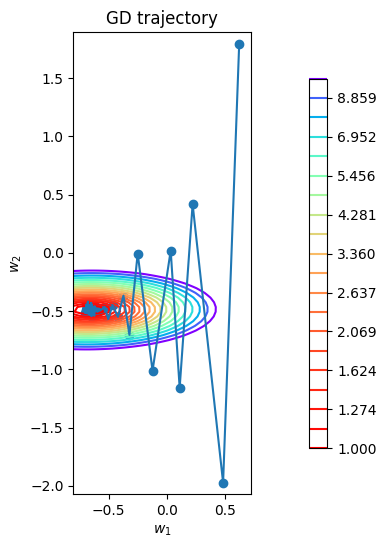

In [1430]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.011, 70, 100)

plot_gd(w_list, X, y, loss)

При увеличении количества объектов по которым проходит стохастический градиентный спуск траектория становится менее хаотичной, что очень подходит под ситуацию. ТО есть если при 7 объектах траетория скакала во все стороны, то сейчас при 70 объектах она близка к траеткории обычного градиентного спуска из-за снижения уровня шума данных, то есть при увеличении выборки параметры вычисляются более ближе к град спуску

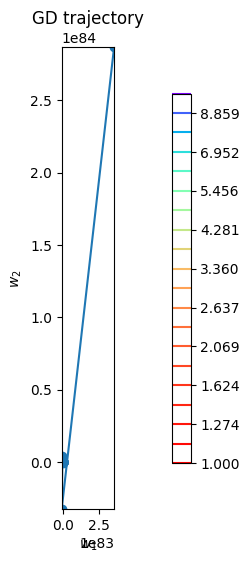

In [1431]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.05, 15, 100)

plot_gd(w_list, X, y, loss)

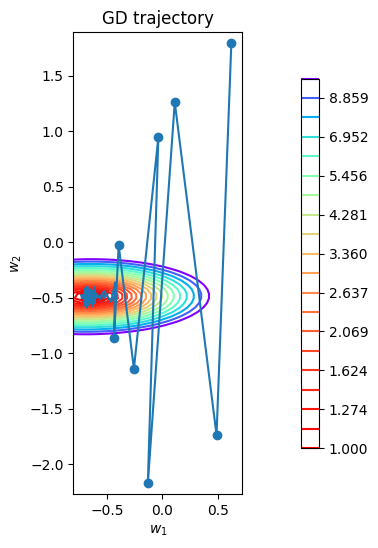

In [1432]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 15, 100)

plot_gd(w_list, X, y, loss)

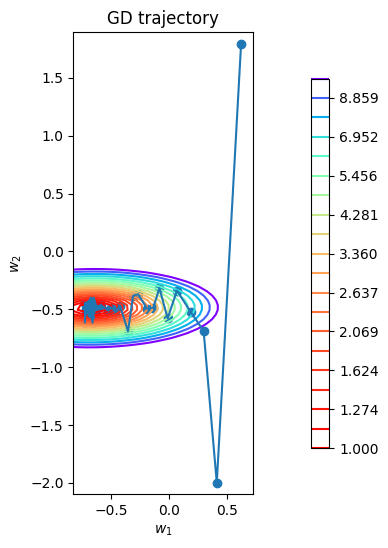

In [1433]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.009, 15, 100)

plot_gd(w_list, X, y, loss)

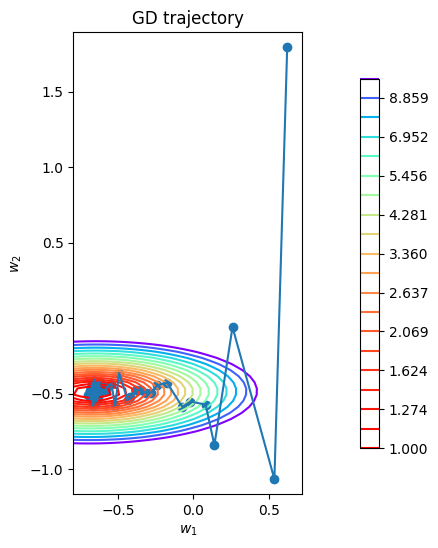

In [1434]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.008, 15, 100)

plot_gd(w_list, X, y, loss)

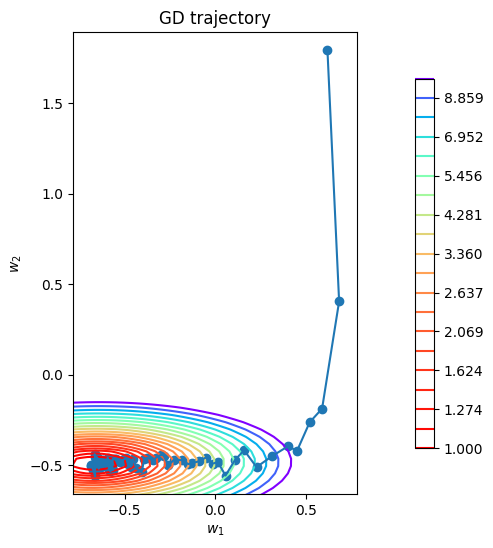

In [1435]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.004, 15, 100)

plot_gd(w_list, X, y, loss)

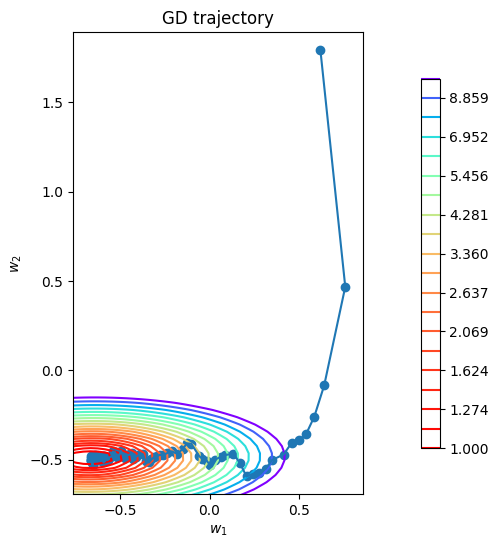

In [1436]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.003, 15, 100)

plot_gd(w_list, X, y, loss)

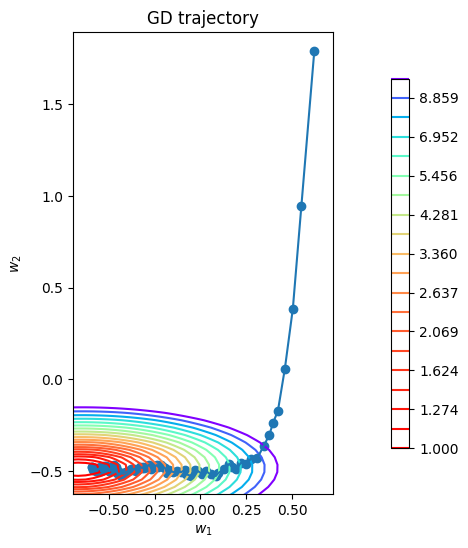

In [1437]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.002, 15, 100)

plot_gd(w_list, X, y, loss)

И еще один вывод: при изменении lr, все что выше 0.01 примерно, оно способствует расходимости град спуска, при постепенном уменьшении lr например от 0.01 до 0.002 необходимо все больше точек для достижения минимума (что похоже на результаты 1.3). Но требуется заметить что хаотчиность точек примерно одинаковая, все это из-за того что размер батча остается постоянным

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [1438]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    traec = [w_init]

    for iter in range(n_iterations):
      batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
      batch = X[batch_indices]
      gradient = loss.calc_grad(batch, y[batch_indices], traec[-1])
      lr_dinamic = lr * (1/(1+iter))**p
      traec.append(traec[-1] - lr_dinamic * gradient)

    return traec

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?

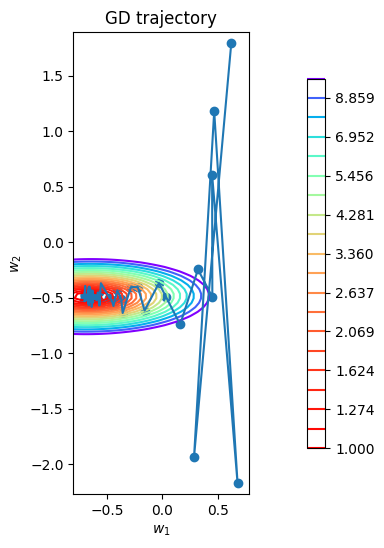

In [1439]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.1, 100)

plot_gd(w_list, X, y, loss)

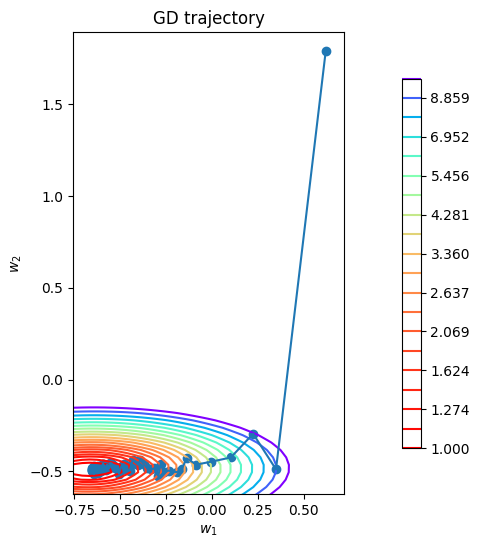

In [1440]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.4, 100)
plot_gd(w_list, X, y, loss)

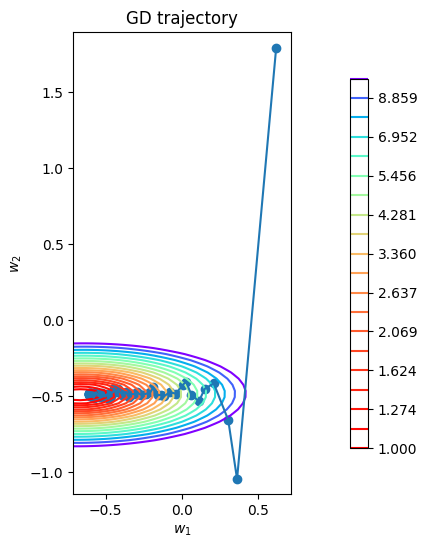

In [1441]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.5, 100)

plot_gd(w_list, X, y, loss)

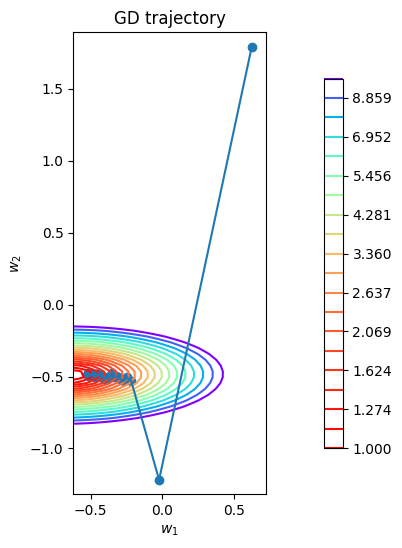

In [1442]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.8, 100)

plot_gd(w_list, X, y, loss)

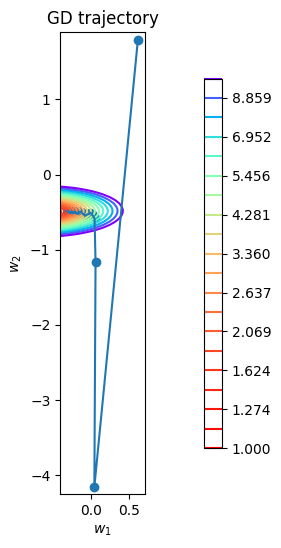

In [1443]:
w_list = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.9, 100)

plot_gd(w_list, X, y, loss)

Итак, некий баланс как можно заметить соблюдается при p=0.4-0.5, там и разброс траетории меньше, и минимум достигается с минимальными телодвижениями. При увеличении p к 0.8-0.9 появляется один шаг, уходящий совсем вниз, после наблюдается возвращение к траектории обычного градиентного спуска, но с большим количеством необходимых точек. При <0.4 наблюдается более хаотическое движение

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

С помощью списочного выражения создаем списки потерь для каждого типа спуска, при подходе к минимуму. а дальше рисуем их, но в логорифмированной шкале, потому что так лучше интерпертировать (ошибка не может быть отрицательной - условие применения логорифмирования)

В итоге получается что обычный градиентный спуск приходит к минимуму быстрее, чем стохастический и тут по моему мнению нет приемуществ стохастического. К тому же на графике представленны ошибки зависимые от колчисетва итераций, а не от времени выполнения. Естесственно град спуск на 10 элементов будет быстрее чем на все 300

И кстати стохастический в начале давал меньшую ошибку примерно до 3-5 итерации, но потом проигрывает обычному

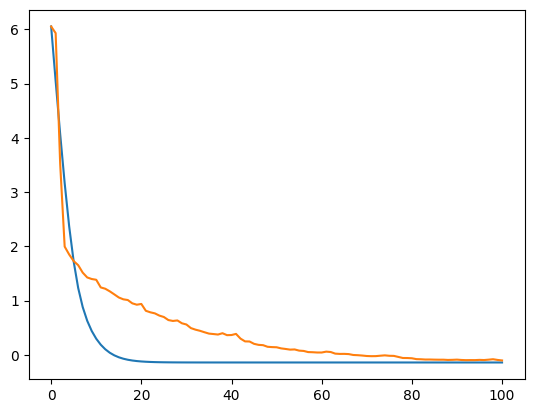

In [1444]:
ordinal = gradient_descent(w_init, X, y, loss, 0.01, 100)
stochastic = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.5, 100)

loss_ordinal = [loss.calc_loss(X, y, w) for w in ordinal]
loss_stochastic = [loss.calc_loss(X, y, w) for w in stochastic]

plt.plot(np.log(loss_ordinal))
plt.plot(np.log(loss_stochastic))

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

используя метод shape узнаем размеры массива https://www.geeksforgeeks.org/python/numpy-array-shape/

инициализируем начальные веса как нули с помощью такой функции https://www.geeksforgeeks.org/numpy/numpy-zeros-python/

In [1477]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        feat_num = X.shape[1]
        w_init = np.zeros(feat_num)
        traec = gradient_descent(w_init, X, y, self.loss, self.lr, 3000)
        self.w = traec[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [1478]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [1479]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [1480]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

Давайте безжалостно удалим строки с пропусками в категориальных признаках, их по одному в каждой выборке, их отсутствие не очень влияет на будущее (те самые строки с пустой 6 колонкой)

In [1481]:
X_raw.isnull().sum()

,0
1,0
2,37
3,0
4,0
5,0
6,2
7,0
8,0
9,0
10,0


Находим те строки где пропущен 6 признак

In [1482]:
X_raw[X_raw[6].isna()]

,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
26,1,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,...,four,98,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30
60,0,NaN,mazda,diesel,std,NaN,sedan,fwd,front,98.8,...,four,122,idi,3.39,3.39,22.7,64.0,4650.0,36,42


Удаляем их

In [1483]:
X_raw = X_raw.drop(26)
y = y.drop(26)

In [1484]:
X_raw = X_raw.drop(60)
y = y.drop(60)

In [1485]:
X_raw.isnull().sum()

,0
1,0
2,36
3,0
4,0
5,0
6,0
7,0
8,0
9,0
10,0


Теперь категориальных пропусков нет, закодируем признаки с помощью get_dummies, не будем заморачиваться и используем one-hot кодировние

In [1486]:
X_raw = pd.get_dummies(X_raw, drop_first=True)

Теперь идем разделять на разные выборки

In [1487]:
from sklearn.model_selection import train_test_split

In [1488]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.3, random_state=42)

Всеми известной комбинацией функций https://www.geeksforgeeks.org/python/python-pandas-isnull-and-notnull/ и суммирование потом по каждому столбцу определяем наличие пропусков. А также заменяем их на медианное значение вычисленное в обучающей группе и в обучающей и в тестовой выборке. Совет об этом дан тут https://browse.library.kiwix.org/content/stackoverflow.com_en_all_2023-11/questions/60363476/impute-missing-values-with-mean-of-column-in-machine-learning

In [1489]:
X_test.isnull().sum()

,0
1,0
2,12
10,0
11,0
12,0
...,...
18_idi,0
18_mfi,0
18_mpfi,0
18_spdi,0


In [1490]:
X_train.isnull().sum()

,0
1,0
2,24
10,0
11,0
12,0
...,...
18_idi,0
18_mfi,0
18_mpfi,0
18_spdi,0


Теперь заполняем пропуски в числовых признаках с помощью функции fillna https://habr.com/ru/companies/otus/articles/797283/. Находим числовые признаки как тут: https://sky.pro/wiki/python/vybor-chislovykh-stolbtsov-v-pandas-funktsiya-is-numeric/

In [1491]:
numeric_cols = X_raw.select_dtypes(include='number').columns

In [1492]:
medi = X_train[numeric_cols].median()
X_train[numeric_cols] = X_train[numeric_cols].fillna(medi)
X_test[numeric_cols] = X_test[numeric_cols].fillna(medi)

In [1493]:
X_train

,1,2,10,11,12,13,14,17,19,20,...,16_three,16_twelve,16_two,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi,18_spfi
142,0,89.0,97.0,173.5,65.4,53.0,2290,108,3.62,2.64,...,False,False,False,True,False,False,False,False,False,False
32,1,101.0,93.7,150.0,64.0,52.6,1940,92,2.91,3.41,...,False,False,False,False,False,False,False,False,False,False
12,0,188.0,101.2,176.8,64.8,54.3,2765,164,3.31,3.19,...,False,False,False,False,False,False,False,True,False,False
36,0,106.0,96.5,167.5,65.2,53.3,2236,110,3.15,3.58,...,False,False,False,False,False,False,False,False,False,False
117,1,154.0,93.7,157.3,63.8,50.6,1967,90,2.97,3.23,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,0,161.0,107.9,186.7,68.4,56.7,3075,120,3.46,2.19,...,False,False,False,False,False,False,False,True,False,False
14,0,110.0,103.5,189.0,66.9,55.7,3230,209,3.62,3.39,...,False,False,False,False,False,False,False,True,False,False
94,1,103.0,94.5,170.2,63.8,53.5,2037,97,3.15,3.29,...,False,False,False,True,False,False,False,False,False,False
181,2,94.0,97.3,171.7,65.5,55.7,2212,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


In [1494]:
X_test

,1,2,10,11,12,13,14,17,19,20,...,16_three,16_twelve,16_two,18_2bbl,18_4bbl,18_idi,18_mfi,18_mpfi,18_spdi,18_spfi
84,1,125.0,96.3,172.4,65.4,51.6,2403,110,3.17,3.46,...,False,False,False,False,False,False,False,False,True,False
15,0,110.0,103.5,193.8,67.9,53.7,3380,209,3.62,3.39,...,False,False,False,False,False,False,False,True,False,False
113,0,161.0,107.9,186.7,68.4,56.7,3252,152,3.70,3.52,...,False,False,False,False,False,True,False,False,False,False
179,2,122.0,97.3,171.7,65.5,55.7,2209,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
78,3,153.0,96.3,173.0,65.4,49.4,2328,122,3.35,3.46,...,False,False,False,True,False,False,False,False,False,False
165,2,134.0,98.4,176.2,65.6,52.0,2551,146,3.62,3.50,...,False,False,False,False,False,False,False,True,False,False
70,0,110.0,120.9,208.1,71.7,56.7,3900,308,3.80,3.35,...,False,False,False,False,False,False,False,True,False,False
69,3,142.0,96.6,180.3,70.5,50.8,3685,234,3.46,3.10,...,False,False,False,False,False,False,False,True,False,False
122,3,186.0,94.5,168.9,68.3,50.2,2778,151,3.94,3.11,...,False,False,False,False,False,False,False,True,False,False
175,3,197.0,102.9,183.5,67.7,52.0,3016,171,3.27,3.35,...,False,False,False,False,False,False,False,True,False,False


Приступаем к масштабированию: с помощью нашего любимого трансофрмера StandardScaler

In [1495]:
from sklearn import preprocessing

normalizer = preprocessing.StandardScaler()
X_train[numeric_cols] = normalizer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = normalizer.transform(X_test[numeric_cols])

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [1496]:
lr = linear_regression.fit(X_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [1497]:
from sklearn.metrics import mean_squared_error

print(f"Train: {mean_squared_error(y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test))}")

Train: 1154438.5214932442
Test: 15044627.664166005


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

Выполняем точь-в-точь как в формуле (матричной) выше, при этом не учитываем свободный член там где это не нужно

In [1498]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        l = X.shape[0]
        predicted = X @ w
        return 1 / l * np.linalg.norm(predicted - y) ** 2 + self.coef * np.linalg.norm(w[:-1]) ** 2

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        predicted = X @ w
        itog_push_grad = 2 / l * X.T @ (predicted - y)
        itog_push_grad[:-1] += 2 * self.coef * w[:-1]
        return itog_push_grad

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [1499]:
linear_regression = LinearRegression(MSEL2Loss(0.03))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [1500]:
lr = linear_regression.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test))}")

Train: 2742965.9319750755
Test: 15655226.542745356


In [1501]:
linear_regression = LinearRegression(MSEL2Loss(0.001))
lr = linear_regression.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test))}")

Train: 1201288.5717430536
Test: 14972892.479096599


In [1502]:
linear_regression = LinearRegression(MSEL2Loss(0.003))
lr = linear_regression.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test))}")

Train: 1350672.0702037115
Test: 14932493.859167252


In [1503]:
linear_regression = LinearRegression(MSEL2Loss(0.008))
lr = linear_regression.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, lr.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, lr.predict(X_test))}")

Train: 1736900.914495863
Test: 14876239.584886814


К сожалению, сильного достижения лучшего результата не получилось, возможно из-за ограниченности выборки (300 строк) (недостаточности данных), удалось только приблизиться к предыдущему значению (это про тренировочную выборку)

Про тестовую: тут есть реальные улучшения, особенно при lambda = 0.008

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

Смотрим как реализуют huberloss в интернете: https://habr.com/ru/articles/918438/ На всякий случай документация по where: https://numpy.org/doc/stable/reference/generated/numpy.where.html

calc_grad осуществляем в похожей форме, только формула матричная будет различаться, необходима как и в calc_loss класса MSEL2Loss транспонированная матрица X.T

np.abs - модуль нампаевский, np.sign - всем известная функция знака

In [1504]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        l = X.shape[0]
        errors = X @ w - y
        huber_loss = np.where(np.abs(errors) <= self.eps, 0.5 * errors ** 2, self.eps * (np.abs(errors) - 0.5 * self.eps))
        return np.sum(huber_loss) / l

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        l = X.shape[0]
        errors = X @ w - y
        huber_grad = np.where(np.abs(errors) <= self.eps, errors, self.eps * np.sign(errors))
        return X.T @ huber_grad / l

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [1534]:
linear_regression = LinearRegression(HuberLoss(40000))

In [1535]:
model_huber = linear_regression.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, model_huber.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, model_huber.predict(X_test))}")

Train: 1233492.9723931225
Test: 17057644.02662544


In [1507]:
linear_regression = LinearRegression(HuberLoss(10000))
model_huber = linear_regression.fit(X_train, y_train)
print(f"Train: {mean_squared_error(y_train, model_huber.predict(X_train))}")
print(f"Test: {mean_squared_error(y_test, model_huber.predict(X_test))}")

Train: 1233772.0055955572
Test: 17061775.18829098


Улучшений нет((( по сравнению с мселосс. На обучающей приближено к начальным, а на тестовой выше на примерно 2-3 миллиона. Это означает что выбросов у нас все таки не очень много и они не влияют, а эту huberLoss лучше использовать в датасетах с большими выбросами, которые играют роль при предсказании

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

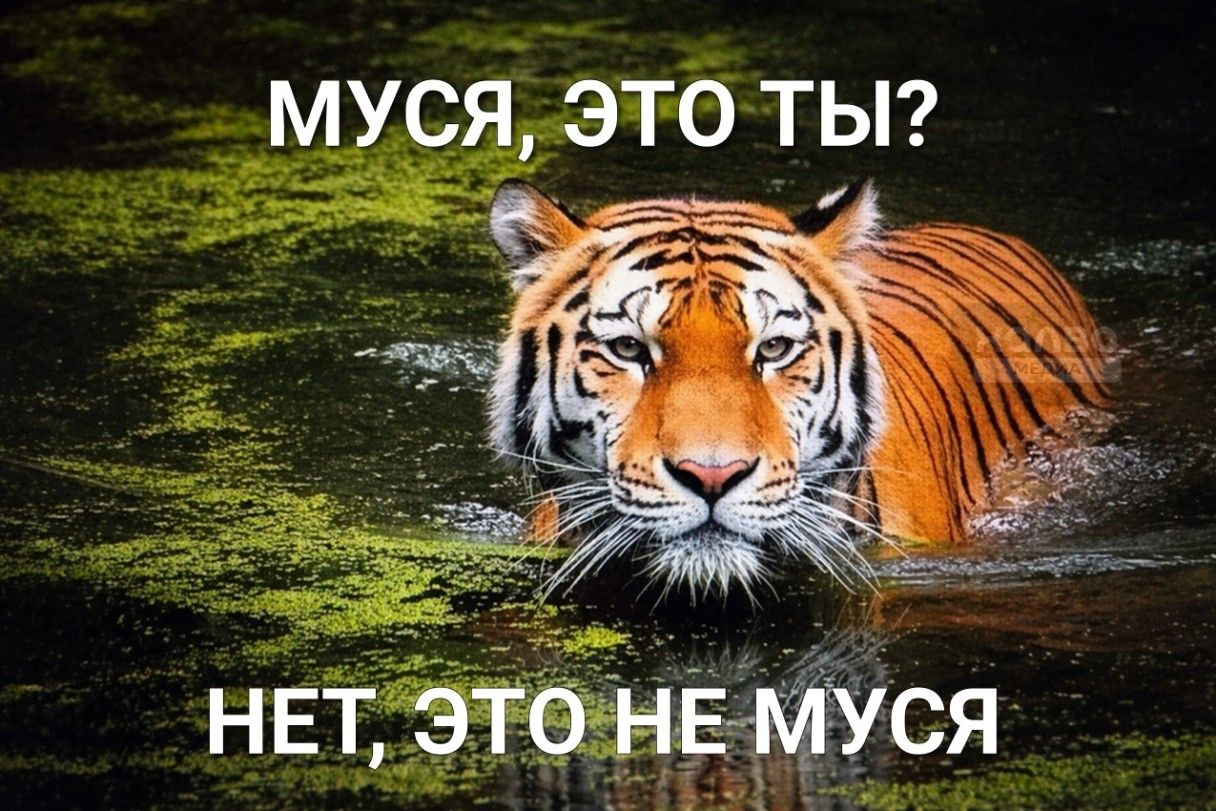

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [1508]:
# -- YOUR CODE HERE -- ʕ•ᴥ•ʔ